In [1]:
import pandas as pd

In [2]:
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race",
    "sex", "capital-gain", "capital-loss", "hours-per-week",
    "native-country", "income"
]

data = pd.read_csv("adult.data", names=columns)

data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
data = pd.read_csv("adult.data", names=columns)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
data.shape

(32561, 15)

In [6]:
data.rename(columns={"sex": "gender"}, inplace=True)

In [7]:
data.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [8]:
data.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
gender            0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [9]:
data.isin([" ?"]).sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
gender               0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [10]:
import numpy as np

data.replace(" ?", np.nan, inplace=True)

In [11]:
data.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
gender               0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [12]:
data = data.dropna()

In [13]:
data.shape

(30162, 15)

In [14]:
data["income"] = data["income"].apply(lambda x: 1 if ">50K" in x else 0)

In [15]:
data["income"].value_counts()

income
0    22654
1     7508
Name: count, dtype: int64

In [16]:
X = data.drop("income", axis=1)
y = data["income"]

In [17]:
sensitive = X["gender"]

In [18]:
X = X.drop("gender", axis=1)

In [19]:
X = pd.get_dummies(X, drop_first=True)

In [20]:
X.shape

(30162, 95)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, sensitive_train, sensitive_test = train_test_split(
    X, y, sensitive, test_size=0.2, random_state=42
)

In [22]:
X_train.shape, X_test.shape

((24129, 95), (6033, 95))

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(hidden_layer_sizes=(64, 32),
                      activation='relu',
                      max_iter=200,
                      random_state=42)

model.fit(X_train, y_train)

C:\Users\Dheeraj\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(64, 32), random_state=42)

In [25]:
y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8286093154317918

In [27]:
fairness_df = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred,
    "gender": sensitive_test
})

fairness_df.head()

,actual,predicted,gender
234,1,0,Male
26879,0,0,Male
19182,1,0,Male
13485,0,0,Male
9625,0,0,Female


In [28]:
male_selection = fairness_df[fairness_df["gender"] == "Male"]["predicted"].mean()
female_selection = fairness_df[fairness_df["gender"] == "Female"]["predicted"].mean()

male_selection, female_selection

(nan, nan)

In [29]:
fairness_df["gender"].unique()

array([' Male', ' Female'], dtype=object)

In [30]:
fairness_df["gender"] = fairness_df["gender"].str.strip()

In [31]:
male_selection = fairness_df[fairness_df["gender"] == "Male"]["predicted"].mean()
female_selection = fairness_df[fairness_df["gender"] == "Female"]["predicted"].mean()

male_selection, female_selection

(np.float64(0.29027504911591356), np.float64(0.10504844467108618))

In [32]:
disparate_impact = female_selection / male_selection
disparate_impact

np.float64(0.36189278062661834)

In [33]:
y_prob = model.predict_proba(X_test)[:, 1]

In [34]:
import numpy as np

# Create new predictions after mitigation
y_pred_mitigated = []

for prob, gender in zip(y_prob, sensitive_test):
    gender = gender.strip()  # remove space
    
    if gender == "Female":
        y_pred_mitigated.append(1 if prob > 0.3 else 0)
    else:
        y_pred_mitigated.append(1 if prob > 0.5 else 0)

y_pred_mitigated = np.array(y_pred_mitigated)

In [35]:
fairness_mitigated = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred_mitigated,
    "gender": sensitive_test.str.strip()
})

In [36]:
male_sel_after = fairness_mitigated[fairness_mitigated["gender"] == "Male"]["predicted"].mean()
female_sel_after = fairness_mitigated[fairness_mitigated["gender"] == "Female"]["predicted"].mean()

male_sel_after, female_sel_after

(np.float64(0.29027504911591356), np.float64(0.13054563997960225))

In [37]:
disparate_impact_after = female_sel_after / male_sel_after
disparate_impact_after

np.float64(0.4497308341767685)

In [38]:
from sklearn.metrics import accuracy_score

accuracy_after = accuracy_score(y_test, y_pred_mitigated)
accuracy_after

0.8262887452345433

In [43]:
fairness_threshold = 0.8

results["Fair? (After)"] = [
    "N/A",
    "Yes" if disparate_impact_after >= fairness_threshold else "No"
]

results

,Metric,Before Mitigation,After Mitigation,Improvement,Fair? (After)
0,Accuracy,0.8286,0.8263,-0.0023,N/A
1,Disparate Impact,0.3619,0.4497,0.0878,No


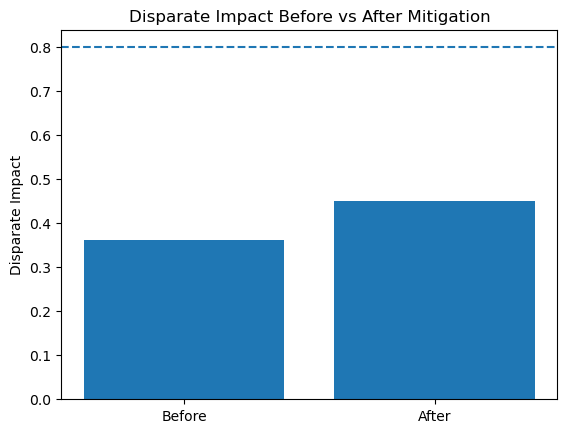

In [44]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(["Before", "After"], 
        [disparate_impact, disparate_impact_after])

plt.axhline(y=0.8, linestyle='--')
plt.title("Disparate Impact Before vs After Mitigation")
plt.ylabel("Disparate Impact")
plt.show()